# Phase 2: AI-Augmented Training Experiments

## Overview

This notebook investigates whether exposing baseline classifiers to AI-generated phishing emails during training improves robustness.

**Experimental Design:**
- The test set is **fixed** from Phase 1 (real emails only) — 5,967 emails
- Only the **training set** is augmented with synthetic phishing emails
- Four augmentation ratios are tested: **0%, 10%, 25%, 50%** of training phishing emails replaced by synthetic ones
- All four classifiers (LR, SVM, RF, XGBoost) are re-trained for each configuration

**Research Question:** Do models trained on augmented data maintain or improve performance when evaluated on real phishing emails?

## 1) Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score
)

import joblib
import os

print('All libraries loaded successfully')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

All libraries loaded successfully
NumPy: 2.3.5
Pandas: 2.3.3


## 2) Load Data

In [ ]:
# ── Load the cleaned real-world dataset from Phase 1 ────────────────────────
real_df = pd.read_csv('../data/processed/clean_emails.csv')
print(f'Real dataset: {real_df.shape[0]:,} emails')
print(real_df['label'].value_counts().rename({0: 'Legitimate', 1: 'Phishing'}))

# ── Load the synthetic phishing emails ──────────────────────────────────────
synth_df = pd.read_csv('../data/processed/synthetic_phishing_emails.csv')

print(f'\nSynthetic dataset: {synth_df.shape[0]:,} emails')
print('Categories:')
print(synth_df['category'].value_counts())

# Ensure text column exists in synthetic data
if 'text' not in synth_df.columns:
    synth_df['text'] = synth_df['subject'] + ' ' + synth_df['body']
synth_df = synth_df[['label', 'text']].copy()

print(f'\nSample synthetic email (first 200 chars):')
print(synth_df['text'].iloc[0][:200])

Real dataset: 29,833 emails
label
Phishing      15447
Legitimate    14386
Name: count, dtype: int64

Synthetic dataset: 1,500 emails
Categories:
category
account_verification    260
mfa_security            250
university              250
bank_payment            250
parcel_delivery         250
prize_lottery           240
Name: count, dtype: int64

Sample synthetic email (first 200 chars):
Your Login Has Been Blocked [Ref: 36685] Dear Customer,

Your login has been blocked due to suspicious activity detected from your IP address.

Unblock your login here:
http://login-blocked-unblock.ne


## 3) Reproduce Phase 1 Train/Test Split

The **same fixed test set** from Phase 1 is used across all experiments.

In [ ]:
from sklearn.model_selection import train_test_split

# Ensure labels are integers (not strings) before splitting
real_df['label'] = real_df['label'].astype(int)
synth_df['label'] = synth_df['label'].astype(int)

# Reproduce the exact Phase 1 split (same random_state=42)
train_real, test_real = train_test_split(
    real_df,
    test_size=0.2,
    random_state=42,
    stratify=real_df['label']
)

print('   Fixed Test Set (unchanged across all experiments)   ')
print(f'Test size: {len(test_real):,} emails')
print(test_real['label'].value_counts().rename({0: 'Legitimate', 1: 'Phishing'}))

print('\n   Real Training Set   ')
print(f'Train size: {len(train_real):,} emails')
print(train_real['label'].value_counts().rename({0: 'Legitimate', 1: 'Phishing'}))

# Isolate training phishing emails (these will be partially replaced)
train_legit  = train_real[train_real['label'] == 0].copy()
train_phish  = train_real[train_real['label'] == 1].copy()

n_train_phish = len(train_phish)
print(f'\nReal phishing emails in training set: {n_train_phish:,}')

   Fixed Test Set (unchanged across all experiments)   
Test size: 5,967 emails
label
Phishing      3090
Legitimate    2877
Name: count, dtype: int64

   Real Training Set   
Train size: 23,866 emails
label
Phishing      12357
Legitimate    11509
Name: count, dtype: int64

Real phishing emails in training set: 12,357


## 4) Build Augmented Training Sets

For each augmentation ratio r ∈ {0%, 10%, 25%, 50%}:
- Keep all legitimate training emails unchanged
- Replace r% of real phishing training emails with synthetic phishing emails
- Total training size stays approximately constant

In [ ]:
def build_augmented_dataset(train_legit, train_phish, synth_df, ratio, random_state=42):
    """
    Build augmented training dataset.
    
    ratio: float — proportion of phishing training emails to replace with synthetic
    """
    np.random.seed(random_state)
    
    n_total_phish = len(train_phish)
    n_synthetic   = int(n_total_phish * ratio)
    n_real_keep   = n_total_phish - n_synthetic
    
    # Sample real phishing emails to keep
    real_phish_keep = train_phish.sample(n=n_real_keep, random_state=random_state)
    
    # Sample synthetic phishing emails
    if n_synthetic > 0:
        synth_sample = synth_df.sample(
            n=n_synthetic,
            random_state=random_state,
            replace=(n_synthetic > len(synth_df))
        )[['label', 'text']].copy()
    else:
        synth_sample = pd.DataFrame(columns=['label', 'text'])
    
    # Combine: all legitimate + kept real phishing + synthetic phishing
    combined = pd.concat([
        train_legit[['label', 'text']],
        real_phish_keep[['label', 'text']],
        synth_sample
    ], ignore_index=True)
    
    combined = combined.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return combined


RATIOS = [0.0, 0.10, 0.25, 0.50]

print('Augmented training set compositions:')
print(f'{"Ratio":>8} | {"Total":>8} | {"Real Phishing":>14} | {"Synthetic":>10} | {"Legitimate":>12}')
print('-' * 65)

for r in RATIOS:
    aug = build_augmented_dataset(train_legit, train_phish, synth_df, r)
    n_phish = aug[aug['label']==1].shape[0]
    n_legit = aug[aug['label']==0].shape[0]
    n_synth = int(n_train_phish * r)
    n_real  = n_phish - n_synth
    print(f'{int(r*100):>7}% | {len(aug):>8,} | {n_real:>14,} | {n_synth:>10,} | {n_legit:>12,}')

Augmented training set compositions:
   Ratio |    Total |  Real Phishing |  Synthetic |   Legitimate
-----------------------------------------------------------------
      0% |   23,866 |         12,357 |          0 |       11,509
     10% |   23,866 |         11,122 |      1,235 |       11,509
     25% |   23,866 |          9,268 |      3,089 |       11,509
     50% |   23,866 |          6,179 |      6,178 |       11,509


## 5) Experiment Runner

Trains all four models on each augmented dataset and records metrics.

In [ ]:
def train_and_evaluate(X_train, y_train, X_test, y_test, ratio_label):
    """
    Train all four models and return metrics dict.
    """
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
        'Linear SVM': LinearSVC(max_iter=2000, random_state=42, C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42,eval_metric='logloss',verbosity=0),
    }
    
    results = []
    
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc       = accuracy_score(y_test, y_pred)
        macro_f1  = f1_score(y_test, y_pred, average='macro')
        prec_phi  = precision_score(y_test, y_pred, pos_label=1)
        rec_phi   = recall_score(y_test, y_pred, pos_label=1)
        f1_phi    = f1_score(y_test, y_pred, pos_label=1)
        prec_leg  = precision_score(y_test, y_pred, pos_label=0)
        rec_leg   = recall_score(y_test, y_pred, pos_label=0)
        f1_leg    = f1_score(y_test, y_pred, pos_label=0)
        
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            'Augmentation': f'{int(ratio_label*100)}%',
            'Model':        model_name,
            'Accuracy':     round(acc, 4),
            'Macro F1':     round(macro_f1, 4),
            'Prec (Phish)': round(prec_phi, 4),
            'Rec (Phish)':  round(rec_phi, 4),
            'F1 (Phish)':   round(f1_phi, 4),
            'Prec (Legit)': round(prec_leg, 4),
            'Rec (Legit)':  round(rec_leg, 4),
            'F1 (Legit)':   round(f1_leg, 4),
            'TP': int(tp), 'TN': int(tn),
            'FP': int(fp), 'FN': int(fn),
        })
        
        print(f'  [{int(ratio_label*100):>3}%] {model_name:<22} '
              f'Acc={acc:.4f}  MacroF1={macro_f1:.4f}  '
              f'Rec(Phi)={rec_phi:.4f}  FP={fp}  FN={fn}')
    
    return results

## 6) Run All Experiments

⏳ This cell trains 4 models × 4 configurations = **16 training runs**. Takes ~2–5 minutes.

In [ ]:
# Fixed test set (same across all experiments)
X_test_raw = test_real['text'].fillna('').values
y_test     = test_real['label'].astype(int).values

all_results = []

for ratio in RATIOS:
    print(f'\n*** Augmentation Ratio: {int(ratio*100)}% ***')
    
    # Build augmented training set
    aug_train = build_augmented_dataset(train_legit, train_phish, synth_df, ratio)
    X_train_raw = aug_train['text'].fillna('').values
    y_train     = aug_train['label'].astype(int).values
    
    print(f'Training set size: {len(aug_train):,} | '
          f'Phishing: {sum(y_train==1):,} | '
          f'Legitimate: {sum(y_train==0):,}')
    
    # Fit TF-IDF on this training set
    tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
    )
    X_train = tfidf.fit_transform(X_train_raw)
    X_test  = tfidf.transform(X_test_raw)
    
    # Train and evaluate all models
    ratio_results = train_and_evaluate(X_train, y_train, X_test, y_test, ratio)
    all_results.extend(ratio_results)

print('\n✅ All experiments complete!')


*** Augmentation Ratio: 0% ***
Training set size: 23,866 | Phishing: 12,357 | Legitimate: 11,509
  [  0%] Logistic Regression    Acc=0.9846  MacroF1=0.9846  Rec(Phi)=0.9926  FP=69  FN=23
  [  0%] Linear SVM             Acc=0.9866  MacroF1=0.9866  Rec(Phi)=0.9880  FP=43  FN=37
  [  0%] Random Forest          Acc=0.9804  MacroF1=0.9804  Rec(Phi)=0.9845  FP=69  FN=48
  [  0%] XGBoost                Acc=0.9775  MacroF1=0.9775  Rec(Phi)=0.9909  FP=106  FN=28

*** Augmentation Ratio: 10% ***
Training set size: 23,866 | Phishing: 12,357 | Legitimate: 11,509
  [ 10%] Logistic Regression    Acc=0.9853  MacroF1=0.9852  Rec(Phi)=0.9929  FP=66  FN=22
  [ 10%] Linear SVM             Acc=0.9868  MacroF1=0.9867  Rec(Phi)=0.9887  FP=44  FN=35
  [ 10%] Random Forest          Acc=0.9807  MacroF1=0.9807  Rec(Phi)=0.9816  FP=58  FN=57
  [ 10%] XGBoost                Acc=0.9777  MacroF1=0.9777  Rec(Phi)=0.9903  FP=103  FN=30

*** Augmentation Ratio: 25% ***
Training set size: 23,866 | Phishing: 12,357 | L

## 7) Results Summary Table

In [ ]:
results_df = pd.DataFrame(all_results)

# Display full table
display_cols = ['Augmentation', 'Model', 'Accuracy', 'Macro F1',
                'Prec (Phish)', 'Rec (Phish)', 'F1 (Phish)',
                'Prec (Legit)', 'Rec (Legit)', 'F1 (Legit)']

print('=== FULL RESULTS TABLE ===')
print(results_df[display_cols].to_string(index=False))

# Save to CSV for report
results_df.to_csv('../outputs/metrics/phase2_results.csv', index=False)
print('\nSaved to ../outputs/metrics/phase2_results.csv')

=== FULL RESULTS TABLE ===
Augmentation               Model  Accuracy  Macro F1  Prec (Phish)  Rec (Phish)  F1 (Phish)  Prec (Legit)  Rec (Legit)  F1 (Legit)
          0% Logistic Regression    0.9846    0.9846        0.9780       0.9926      0.9852        0.9919       0.9760      0.9839
          0%          Linear SVM    0.9866    0.9866        0.9861       0.9880      0.9871        0.9871       0.9851      0.9861
          0%       Random Forest    0.9804    0.9804        0.9778       0.9845      0.9811        0.9832       0.9760      0.9796
          0%             XGBoost    0.9775    0.9775        0.9665       0.9909      0.9786        0.9900       0.9632      0.9764
         10% Logistic Regression    0.9853    0.9852        0.9789       0.9929      0.9859        0.9922       0.9771      0.9846
         10%          Linear SVM    0.9868    0.9867        0.9858       0.9887      0.9872        0.9878       0.9847      0.9862
         10%       Random Forest    0.9807    0.9807    

## 8) Confusion Matrix Analysis — Phase 2 (50% Augmentation)

The confusion matrix below shows the TP, TN, FP, and FN values for all four 
models at the 50% augmentation level, allowing direct comparison with Phase 1 
baseline confusion matrix results.

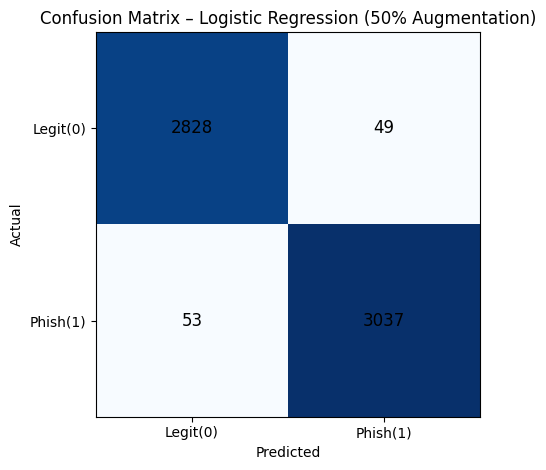

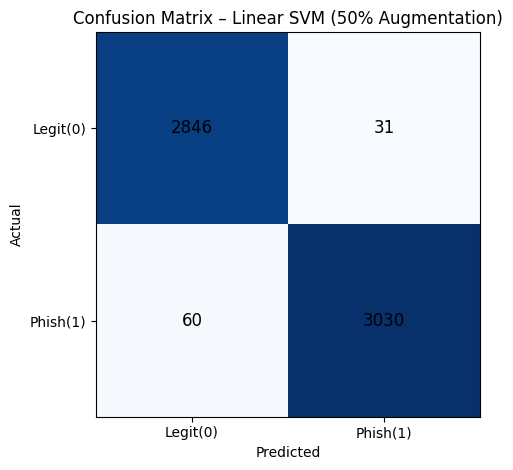

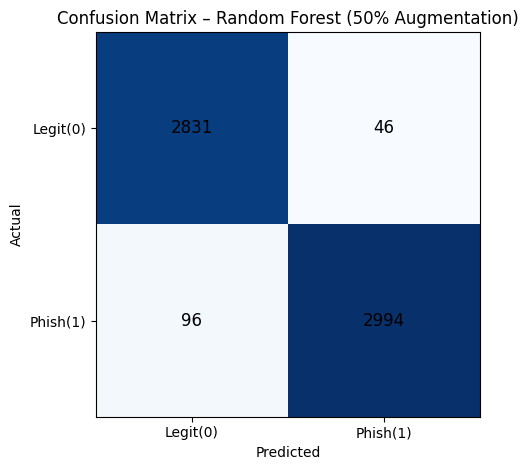

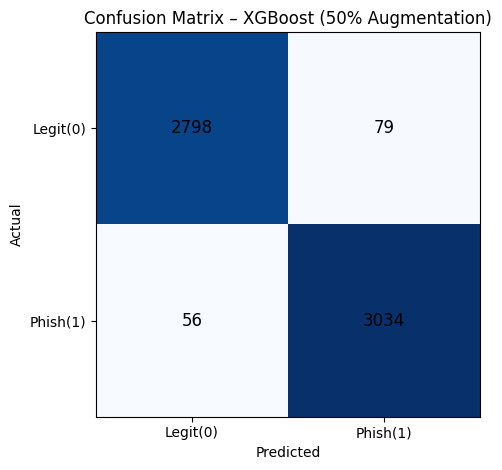

In [ ]:
import numpy as np

for row in all_results:
    if row['Augmentation'] == '50%':
        # Reconstruct confusion matrix from stored values
        cm = np.array([[row['TN'], row['FP']], 
                       [row['FN'], row['TP']]])
        plt.figure()
        plt.imshow(cm, cmap='Blues')
        plt.title(f"Confusion Matrix – {row['Model']} (50% Augmentation)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.xticks([0, 1], ["Legit(0)", "Phish(1)"])
        plt.yticks([0, 1], ["Legit(0)", "Phish(1)"])
        for (i, j), val in zip([(0,0),(0,1),(1,0),(1,1)], cm.flatten()):
            plt.text(j, i, str(val), ha='center', va='center', fontsize=12)
        plt.tight_layout()
        plt.savefig(f"../outputs/figures/cm_50pct_{row['Model'].replace(' ', '_')}.png", dpi=150)
        plt.show()

## 9) Visualisations

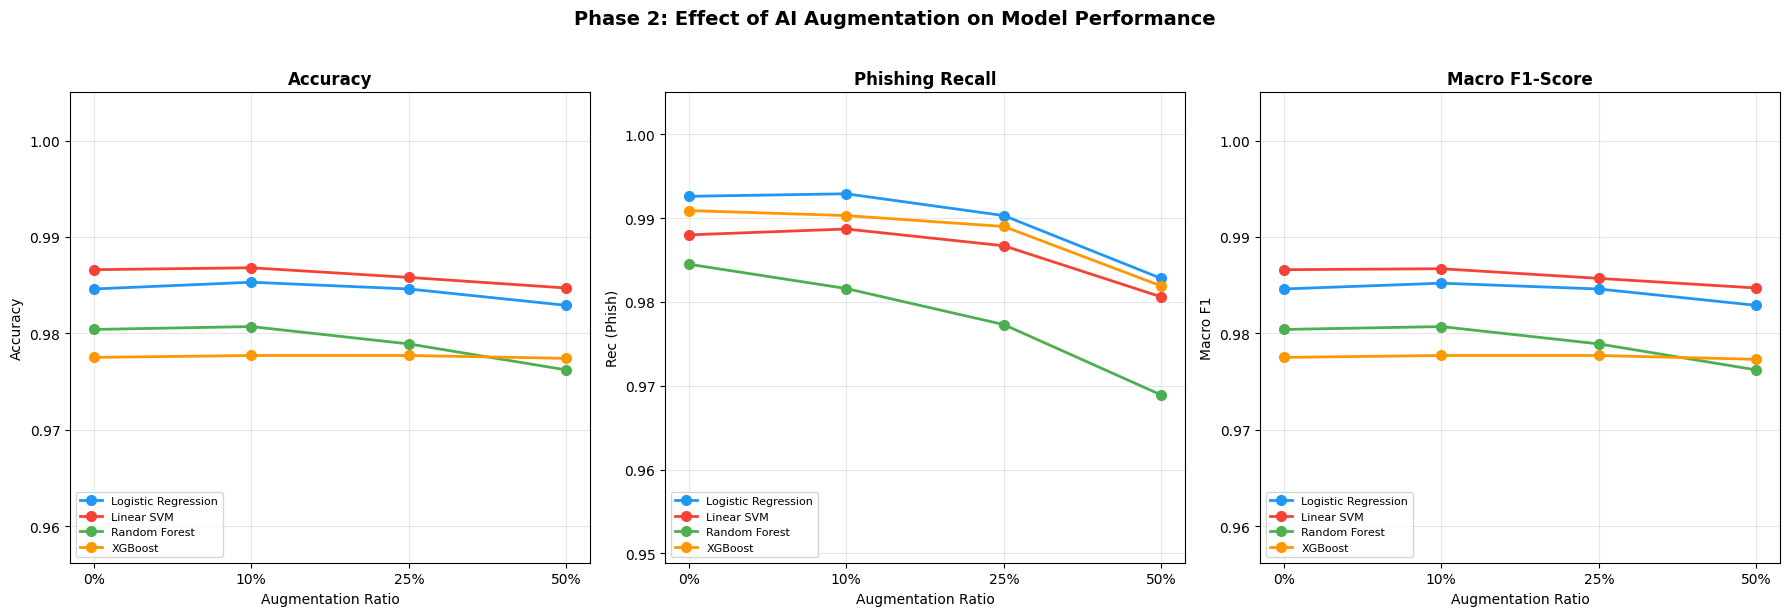

Saved: phase2_performance_trends.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phase 2: Effect of AI Augmentation on Model Performance',
             fontsize=14, fontweight='bold', y=1.02)

model_names  = results_df['Model'].unique()
aug_labels   = ['0%', '10%', '25%', '50%']
colours      = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
metrics      = ['Accuracy', 'Rec (Phish)', 'Macro F1']
metric_titles= ['Accuracy', 'Phishing Recall', 'Macro F1-Score']

for ax, metric, title in zip(axes, metrics, metric_titles):
    for colour, model in zip(colours, model_names):
        model_data = results_df[results_df['Model'] == model]
        values = [model_data[model_data['Augmentation'] == r][metric].values[0]
                  for r in aug_labels]
        ax.plot(aug_labels, values, marker='o', label=model,
                color=colour, linewidth=2, markersize=7)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Augmentation Ratio', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([results_df[metric].min() - 0.02, 1.005])

plt.tight_layout()
plt.savefig('../outputs/figures/phase2_performance_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase2_performance_trends.png')

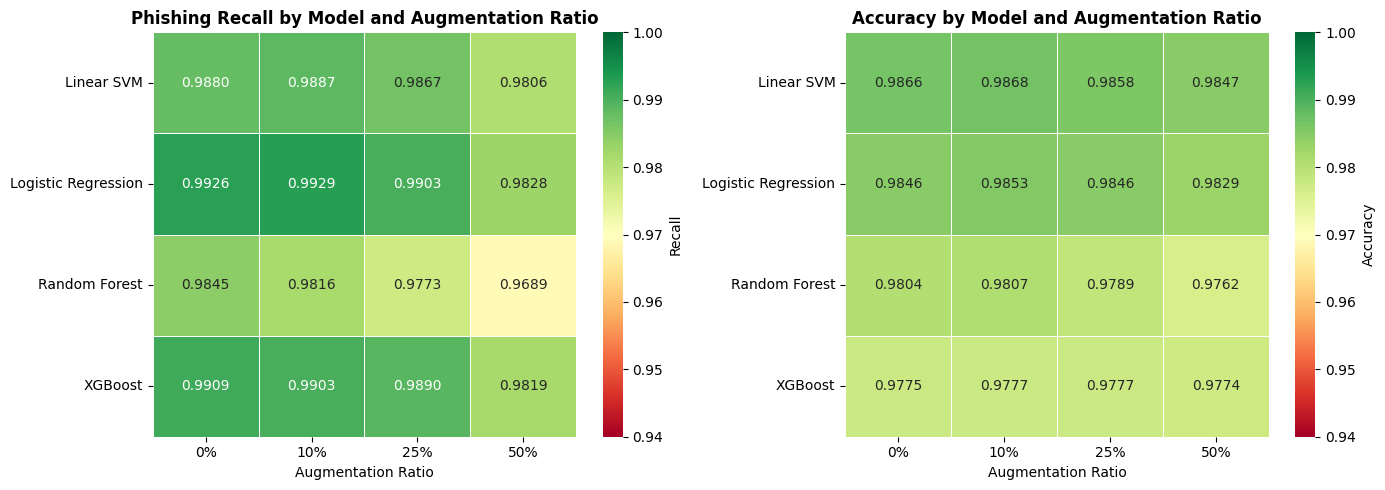

Saved: phase2_heatmaps.png


In [ ]:
# Heatmap: Phishing Recall across all configurations
pivot_rec = results_df.pivot(index='Model', columns='Augmentation', values='Rec (Phish)')
pivot_rec = pivot_rec[['0%', '10%', '25%', '50%']]  # ensure column order

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_rec, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.94, vmax=1.0, ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Recall'})
axes[0].set_title('Phishing Recall by Model and Augmentation Ratio',
                  fontweight='bold')
axes[0].set_xlabel('Augmentation Ratio')
axes[0].set_ylabel('')

pivot_acc = results_df.pivot(index='Model', columns='Augmentation', values='Accuracy')
pivot_acc = pivot_acc[['0%', '10%', '25%', '50%']]

sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.94, vmax=1.0, ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Accuracy'})
axes[1].set_title('Accuracy by Model and Augmentation Ratio',
                  fontweight='bold')
axes[1].set_xlabel('Augmentation Ratio')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/figures/phase2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase2_heatmaps.png')

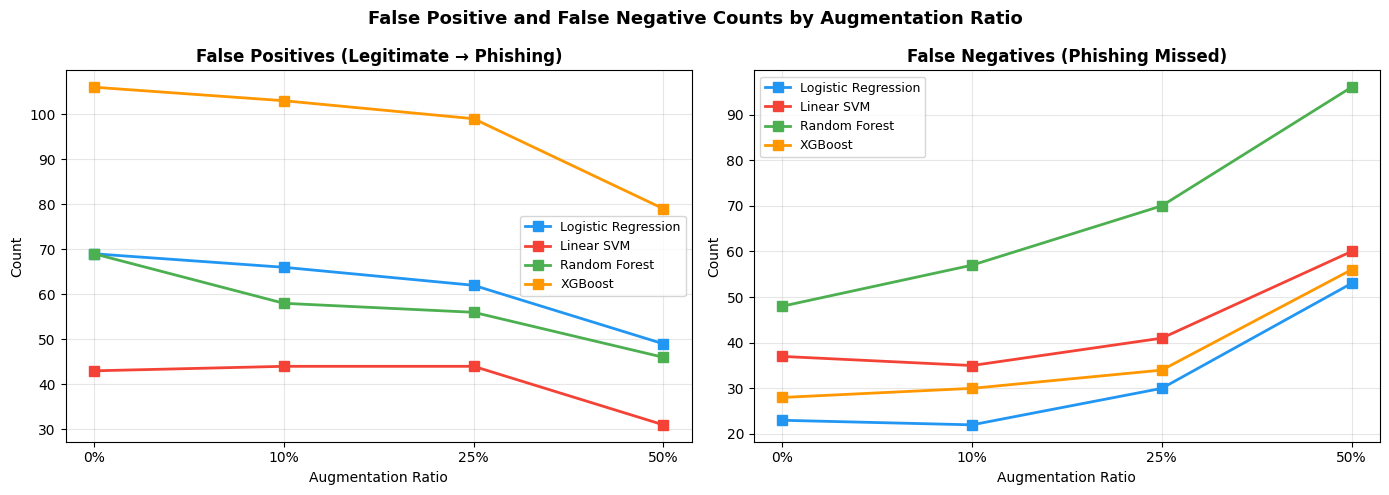

Saved: phase2_fp_fn_trends.png


In [ ]:
# False Positive / False Negative trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('False Positive and False Negative Counts by Augmentation Ratio',
             fontsize=13, fontweight='bold')

for colour, model in zip(colours, model_names):
    model_data = results_df[results_df['Model'] == model]
    fp_vals = [model_data[model_data['Augmentation'] == r]['FP'].values[0] for r in aug_labels]
    fn_vals = [model_data[model_data['Augmentation'] == r]['FN'].values[0] for r in aug_labels]
    
    axes[0].plot(aug_labels, fp_vals, marker='s', label=model,
                 color=colour, linewidth=2, markersize=7)
    axes[1].plot(aug_labels, fn_vals, marker='s', label=model,
                 color=colour, linewidth=2, markersize=7)

axes[0].set_title('False Positives (Legitimate → Phishing)', fontweight='bold')
axes[0].set_xlabel('Augmentation Ratio')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('False Negatives (Phishing Missed)', fontweight='bold')
axes[1].set_xlabel('Augmentation Ratio')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/phase2_fp_fn_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase2_fp_fn_trends.png')

## 10) Key Findings Summary

In [ ]:
print('=' * 70)
print('PHASE 2 KEY FINDINGS SUMMARY')
print('=' * 70)

# Best model per augmentation ratio
print('\nBest model at each augmentation level (by Macro F1):')
for aug in aug_labels:
    subset = results_df[results_df['Augmentation'] == aug]
    best   = subset.loc[subset['Macro F1'].idxmax()]
    print(f'  {aug:>4}: {best["Model"]:<22} '
          f'Accuracy={best["Accuracy"]:.4f}  '
          f'MacroF1={best["Macro F1"]:.4f}  '
          f'Rec(Phi)={best["Rec (Phish)"]:.4f}')

# Overall best configuration
best_overall = results_df.loc[results_df['Macro F1'].idxmax()]
print(f'\nBest overall configuration:')
print(f'  Model: {best_overall["Model"]}')
print(f'  Augmentation: {best_overall["Augmentation"]}')
print(f'  Accuracy: {best_overall["Accuracy"]:.4f}')
print(f'  Macro F1: {best_overall["Macro F1"]:.4f}')
print(f'  Phishing Recall: {best_overall["Rec (Phish)"]:.4f}')
print(f'  False Negatives: {best_overall["FN"]}')
print(f'  False Positives: {best_overall["FP"]}')

# Recall threshold check (must be >= 0.95)
print('\nPhishing Recall threshold check (≥ 0.95):')
for _, row in results_df.iterrows():
    status = '✅' if row['Rec (Phish)'] >= 0.95 else '❌'
    print(f'  {status} [{row["Augmentation"]:>4}] {row["Model"]:<22} Rec={row["Rec (Phish)"]:.4f}')

print('\n' + '=' * 70)

PHASE 2 KEY FINDINGS SUMMARY

Best model at each augmentation level (by Macro F1):
    0%: Linear SVM             Accuracy=0.9866  MacroF1=0.9866  Rec(Phi)=0.9880
   10%: Linear SVM             Accuracy=0.9868  MacroF1=0.9867  Rec(Phi)=0.9887
   25%: Linear SVM             Accuracy=0.9858  MacroF1=0.9857  Rec(Phi)=0.9867
   50%: Linear SVM             Accuracy=0.9847  MacroF1=0.9847  Rec(Phi)=0.9806

Best overall configuration:
  Model: Linear SVM
  Augmentation: 10%
  Accuracy: 0.9868
  Macro F1: 0.9867
  Phishing Recall: 0.9887
  False Negatives: 35
  False Positives: 44

Phishing Recall threshold check (≥ 0.95):
  ✅ [  0%] Logistic Regression    Rec=0.9926
  ✅ [  0%] Linear SVM             Rec=0.9880
  ✅ [  0%] Random Forest          Rec=0.9845
  ✅ [  0%] XGBoost                Rec=0.9909
  ✅ [ 10%] Logistic Regression    Rec=0.9929
  ✅ [ 10%] Linear SVM             Rec=0.9887
  ✅ [ 10%] Random Forest          Rec=0.9816
  ✅ [ 10%] XGBoost                Rec=0.9903
  ✅ [ 25%] Logist

## 10. Comparison: Phase 1 vs Best Phase 2 Configuration

Phase 1 vs Phase 2 (50% Augmentation) Comparison:
                  Phase               Model  Accuracy  Macro F1  Rec (Phish)  Prec (Phish)
 Phase 1 (0% Synthetic)          Linear SVM    0.9849    0.9800       0.9900        0.9800
Phase 2 (50% Synthetic)          Linear SVM    0.9847    0.9847       0.9806        0.9899
 Phase 1 (0% Synthetic) Logistic Regression    0.9839    0.9800       0.9900        0.9800
Phase 2 (50% Synthetic) Logistic Regression    0.9829    0.9829       0.9828        0.9841
 Phase 1 (0% Synthetic)       Random Forest    0.9806    0.9800       0.9800        0.9800
Phase 2 (50% Synthetic)       Random Forest    0.9762    0.9762       0.9689        0.9849
 Phase 1 (0% Synthetic)             XGBoost    0.9618    0.9600       0.9900        0.9400
Phase 2 (50% Synthetic)             XGBoost    0.9774    0.9773       0.9819        0.9746


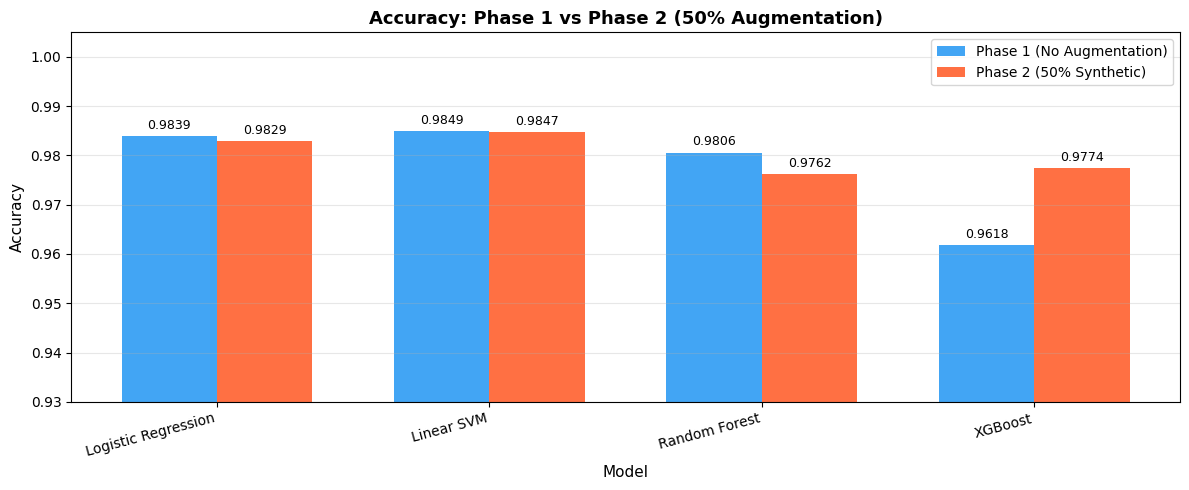

Saved: phase2_vs_phase1.png


In [ ]:
# Phase 1 baseline results (from notebook 02)
phase1 = pd.DataFrame([
     {'Model': 'Logistic Regression', 'Accuracy': 0.9839, 'Macro F1': 0.9800,
     'Rec (Phish)': 0.99, 'Prec (Phish)': 0.98},
    {'Model': 'Linear SVM',          'Accuracy': 0.9849, 'Macro F1': 0.9800,
     'Rec (Phish)': 0.99, 'Prec (Phish)': 0.98},
    {'Model': 'Random Forest',       'Accuracy': 0.9806, 'Macro F1': 0.9800,
     'Rec (Phish)': 0.98, 'Prec (Phish)': 0.98},
    {'Model': 'XGBoost',             'Accuracy': 0.9618, 'Macro F1': 0.9600,
     'Rec (Phish)': 0.99, 'Prec (Phish)': 0.94}
])
phase1['Phase'] = 'Phase 1 (0% Synthetic)'

# Phase 2 best (50% augmentation) for comparison
phase2_50 = results_df[results_df['Augmentation'] == '50%'][
    ['Model', 'Accuracy', 'Macro F1', 'Rec (Phish)', 'Prec (Phish)']].copy()
phase2_50['Phase'] = 'Phase 2 (50% Synthetic)'

comparison = pd.concat([phase1, phase2_50], ignore_index=True)

print('Phase 1 vs Phase 2 (50% Augmentation) Comparison:')
print(comparison[['Phase', 'Model', 'Accuracy', 'Macro F1', 'Rec (Phish)', 'Prec (Phish)']]
      .sort_values(['Model', 'Phase'])
      .to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(phase1))
width  = 0.35
bars1  = ax.bar(x - width/2, phase1['Accuracy'], width,
                label='Phase 1 (No Augmentation)', color='#2196F3', alpha=0.85)
bars2  = ax.bar(x + width/2, phase2_50['Accuracy'].values, width,
                label='Phase 2 (50% Synthetic)', color='#FF5722', alpha=0.85)

ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy: Phase 1 vs Phase 2 (50% Augmentation)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(phase1['Model'], rotation=15, ha='right')
ax.legend(fontsize=10)
ax.set_ylim([0.93, 1.005])
ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/phase2_vs_phase1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase2_vs_phase1.png')

## 11. Save Results

In [ ]:
os.makedirs('../outputs/metrics', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

results_df.to_csv('../outputs/metrics/phase2_results.csv', index=False)
comparison.to_csv('../outputs/metrics/phase2_vs_phase1_comparison.csv', index=False)

print('Files saved:')
print('  ../outputs/phase2_results.csv')
print('  ../outputs/phase2_vs_phase1_comparison.csv')
print('  ../outputs/phase2_performance_trends.png')
print('  ../outputs/phase2_heatmaps.png')
print('  ../outputs/phase2_fp_fn_trends.png')
print('  ../outputs/phase2_vs_phase1.png')
print('\n✅ Phase 2 completed.')

Files saved:
  ../outputs/phase2_results.csv
  ../outputs/phase2_vs_phase1_comparison.csv
  ../outputs/phase2_performance_trends.png
  ../outputs/phase2_heatmaps.png
  ../outputs/phase2_fp_fn_trends.png
  ../outputs/phase2_vs_phase1.png

✅ Phase 2 completed.
